### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 7</center>
---

### Overview

The first objective of this exercise is to continue studying spatial smoothing filters. The second objective is to study the fundamentals of the differentiation of images. Besides some other test images, the following images can be used for a systematic analysis of the differentiation.

<table>
<tr style="font-weight:bold;">
    <td>Name</td>
    <td>Image</td>
    <td>Characteristics</td>
</tr>
<tr>
    <td>h-pattern.png</td>
    <td><img src="images/h-pattern.png" /></td>
    <td>Different gray-level profiles</td>
</tr>
<tr>
    <td>h-gradient-s00.png</td>
    <td><img src="images/h-gradient-s00.png" /></td>
    <td>Gray-level ramp</td>
</tr>
<tr>
    <td>h-gradient-s01.png</td>
    <td><img src="images/h-gradient-s01.png" /></td>
    <td>Gray-level ramp with additional Gaussian noise (sigma = 1.0)</td>
</tr>
<tr>
    <td>h-gradient-s10.png</td>
    <td><img src="images/h-gradient-s10.png" /></td>
    <td>Gray-level ramp with additional Gaussian noise (sigma = 10.0)</td>
</tr>
</table>

All of these images have the same size of $30 \times 300$ pixel.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 7.1</span> Gaussian Filter Masks

In 2D, an isotropic (i. e. circularly symmetric) Gaussian centered at $(x,y) = (0,0)$ has the form:

$$
G(x, y) = K e^{-\dfrac{x^2 + y^2}{2 \sigma^2}}
\hspace{1cm}\mathrm{or}\hspace{1cm}
G(r) = K e^{-\dfrac{r^2}{2 \sigma^2}}
$$

In this equation, $r$ is the distance from the center of the mask. As the mask (or the final filtering result) is usually normalized (to equal the intensity and to avoid bias) by the sum of the coefficients, the constant $K$ can be set to 1 (instead of $1/2\pi\sigma^2$). At a distance larger than $3\sigma$ from the mean, the values of the Gaussian are so small that they can be ignored. Therefore, the size of a Gaussian kernel can be chosen as $\lceil 6\sigma \times 6\sigma \rceil$, rounded to the next odd integer (e.g., 7 for $\sigma = 1$). In practice, it is often sufficient to use $\lceil 3\sigma \times 3\sigma \rceil$.

For the filtering, you can use the function `filter_image` from the last exercise or the OpenCV function <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04">`filter2D` ↗</a>.

1. Write a function to create a Gaussian filter mask with the size $\lceil 3\sigma \times 3\sigma \rceil$ (see above).
2. Plot the mask coefficients of the middle row (or column) for different values of $\sigma$.
3. Test the function for the image *testpattern-512.png* for $\sigma = 1, 3, 7$. Plot and analyze the results.

In [2]:
# write your code here

# compute gaussian mask of odd size with ⌈3*sigma⌉ x ⌈3*sigma⌉
def gaussian_mask(sigma):
    # ...
    sz = int(np.ceil(3*sigma))
    if sz%2 == 0:
        sz = sz+1

    g = np.zeros(shape=[sz, sz], dtype=np.float64)
    c = int(sz/2)

    for row in range(sz):
        for col in range(sz):
            r2 = (row-c)**2 + (col-c)**2
            g[row, col] = np.exp(-r2/(2*sigma**2))
    
    return g, sz

In [3]:
#gaussian exam
def gaussian(sigma, n):
    # create empty mask
    g = np.zeros(shape=[n, n], dtype=np.float64) 
    rows, cols = g.shape
    c = int(n/2)

    for row in range(rows):
        for col in range(cols):
            r2 = (row-c)**2 + (col-c)**2
            g[row, col] = np.exp(-r2/(2*sigma**2))
    return g

In [15]:
g = 12*gaussian(0.9, 3)
g = g.astype('int64')
print(g)

[[ 3  6  3]
 [ 6 12  6]
 [ 3  6  3]]


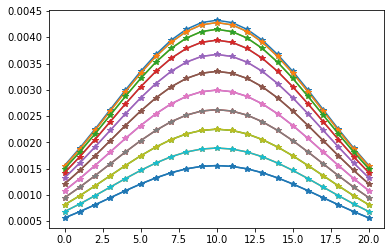

In [34]:
g, sz = gaussian_mask(7.0) #7.0
plt.plot(g[:,:]/np.sum(g), marker='*')
plt.show()

In [32]:
g/np.sum(g)

array([[0.00056177, 0.00068195, 0.00081113, 0.00094529, 0.00107938,
        0.0012076 , 0.00132375, 0.00142177, 0.00149619, 0.0015427 ,
        0.00155852, 0.0015427 , 0.00149619, 0.00142177, 0.00132375,
        0.0012076 , 0.00107938, 0.00094529, 0.00081113, 0.00068195,
        0.00056177],
       [0.00068195, 0.00082786, 0.00098467, 0.00114753, 0.00131032,
        0.00146596, 0.00160697, 0.00172595, 0.00181629, 0.00187276,
        0.00189196, 0.00187276, 0.00181629, 0.00172595, 0.00160697,
        0.00146596, 0.00131032, 0.00114753, 0.00098467, 0.00082786,
        0.00068195],
       [0.00081113, 0.00098467, 0.00117119, 0.0013649 , 0.00155852,
        0.00174365, 0.00191137, 0.00205289, 0.00216034, 0.0022275 ,
        0.00225035, 0.0022275 , 0.00216034, 0.00205289, 0.00191137,
        0.00174365, 0.00155852, 0.0013649 , 0.00117119, 0.00098467,
        0.00081113],
       [0.00094529, 0.00114753, 0.0013649 , 0.00159065, 0.00181629,
        0.00203205, 0.0022275 , 0.00239243, 0.0025176

In [23]:
# filter given image with given m x n mask
def filter_image(img, mask):
    # compute offset / padding size
    m, n = mask.shape # size of the mask (m x n = rows x cols)
    if (m%2==0) or (n%2==0):
        print('returning main image')
        return img
    
    bh = int(m/2)
    bw = int(n/2)

    img_pad = cv2.copyMakeBorder(img, bh, bh, bw, bw, cv2.BORDER_CONSTANT)
    rows, cols = img_pad.shape
    res = np.zeros(shape=[rows, cols], dtype=np.float64)

    for row in range(bh, rows-bh):
        for col in range(bw, cols-bw):
            nbh = img_pad[row-bh:row+bh+1, col-bw:col+bw+1]
            tmp = np.multiply(mask, nbh)
            tmp = np.sum(tmp)
            res[row, col] = tmp
            
    res = res/(m*n)
    
    res = res[bh:rows-bh, bw:cols-bw]
    return res
    

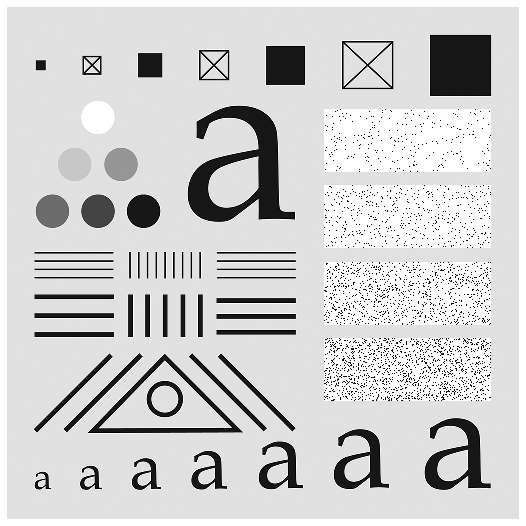

In [24]:
img = cv2.imread('images/testpattern-512.png', 0)
plot_img_orig(img)

In [25]:
masked = filter_image(img, g)

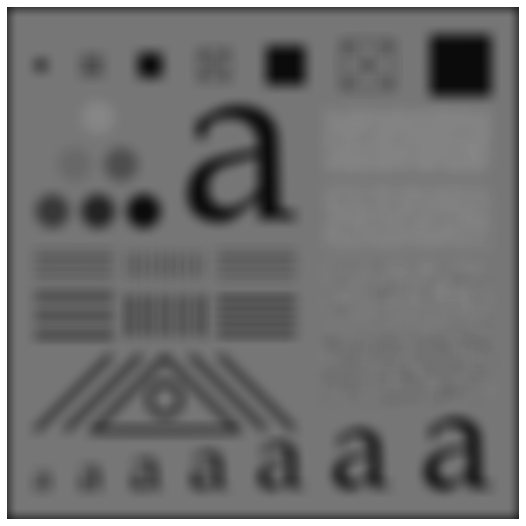

In [26]:
plot_img_orig(masked)

In [43]:
g, sz = gaussian_mask(3.0)
norm = g/np.sum(g) #gaussian normalized.
sum(sum(norm)) 


1.0

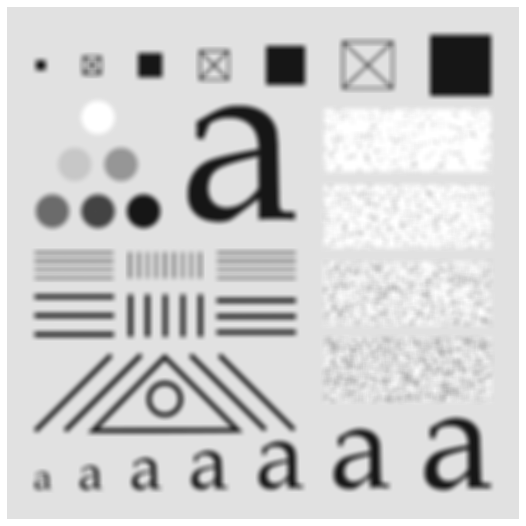

In [44]:
res_s03 = cv2.filter2D(img, cv2.CV_64F, g/np.sum(g))
plot_img_orig(res_s03)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 7.2</span> Comparison of Gaussian and Box Filters

Gaussian filters and box filters have different smoothing characteristics, of which some of them are not apparent at first glance. The objective of this task is to study these differences. For the box filters, you can use the function `mean_filter` from the last exercise or the OpenCV function <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga8c45db9afe636703801b0b2e440fce37">`blur` ↗</a>.

Implement / solve the following tasks:
1. Compare the results of the mean (average) filter when using the same filter sizes as in the previous task.
2. Compare the results for the image *white-bar.png* for a filter size of $25 \times 25$.
3. Plot and compare the intensity profiles along the middle row of the filtered images.

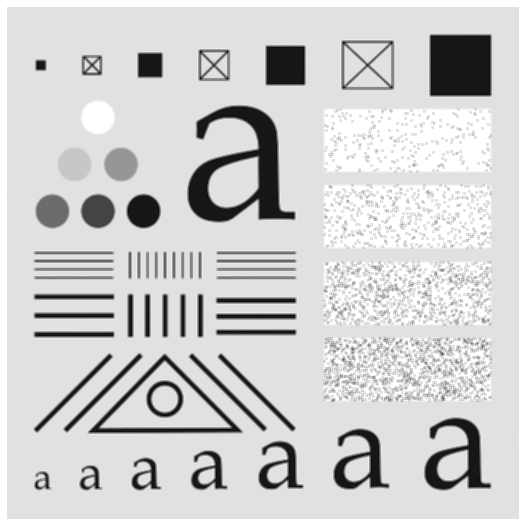

In [46]:
# write your code here
ma = cv2.blur(img, (3,3))
plot_img_orig(ma)

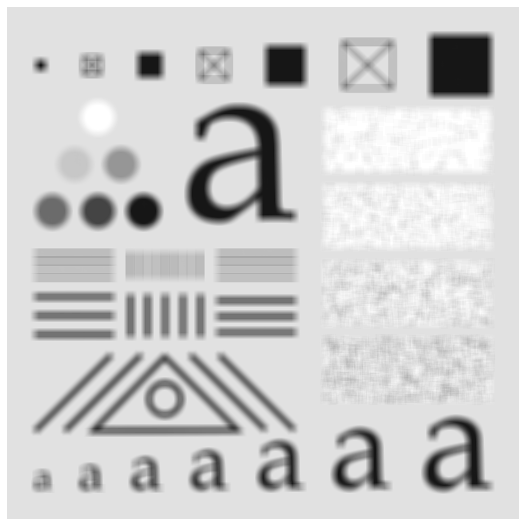

In [47]:
ma = cv2.blur(img, (9,9))
plot_img_orig(ma)

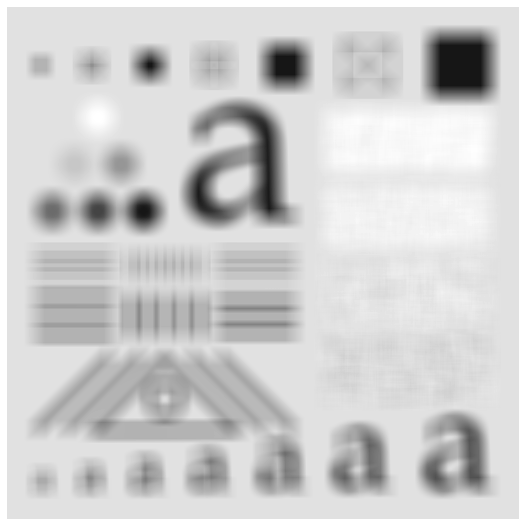

In [48]:
ma = cv2.blur(img, (21, 21))
plot_img_orig(ma)

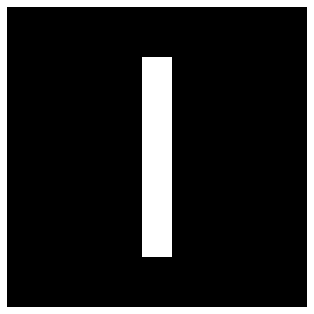

In [49]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/white-bar.png', 0)
plot_img_orig(img)

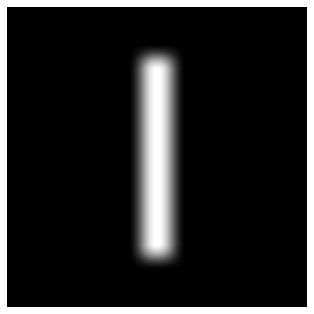

In [50]:
# 25 x 25 Gaussian
g, sz = gaussian_mask(8.0)
res_s08 = cv2.filter2D(img, cv2.CV_64F, g/np.sum(g))
plot_img_orig(res_s08)

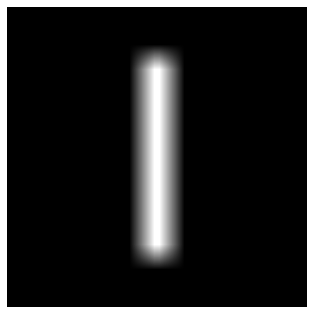

In [51]:
# 25 x 25 box filter
box_25_25 = cv2.blur(img, (25, 25))
plot_img_orig(box_25_25)

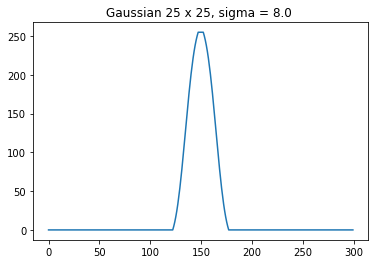

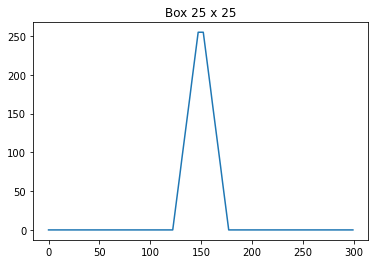

In [55]:
# plot the intensity profiles
plt.plot(res_s08[100,:])
plt.title("Gaussian 25 x 25, sigma = 8.0 ")
plt.show()

plt.plot(box_25_25[100,:])
plt.title("Box 25 x 25")
plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 7.3</span> Ranking (Median) Filter

Ranking filters (also referred to as order-statistics filters) are non-linear spatial filters whose response is based on ranking the pixels contained in the image area encompassed by the filter, and then replacing the value of the center pixel with the value determined by the ranking result. The best-known example in this category is the median filter. Median filters can effectively reduce noise with less blurring than linear filters. A drawback of median filters is that they are computationally expensive due to the sorting.

Implement / solve the following tasks:
1. Write a function for median filtering a given image corresponding to a $n\times n$ mask ($n$ should be odd) using reflection padding. You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.sort.html">`sort` ↗</a> from Numpy for sorting.
2. Test the function for the images *lena-noise-1.png* and *lena-noise-2.png* for $n = 3, 9$. Plot and analyze the results.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga564869aa33e58769b4469101aac458f9">`medianBlur` ↗</a>.

In [17]:
# write your code here

# median filter given image corresponding to n x n mask (n must be odd)
def median_filter(img, n):
    # compute offset / padding size
    b = int(n / 2)
    k = int(n**2/2)

    img_pad = cv2.copyMakeBorder(img, b,b,b,b, cv2.BORDER_CONSTANT)
    rows, cols = img_pad.shape
    res = np.zeros(shape=[rows, cols], dtype=np.uint32)

    for row in range(b, rows-b):
        for col in range(b, cols-b):
            nbh = img_pad[row-b:row+b+1, col-b:col+b+1]
            nbh = nbh.flatten()
            nbh = np.sort(nbh)
            res[row, col] = nbh[k]
    res = res[b:rows-b, b:cols-b]

    return res
    # ...

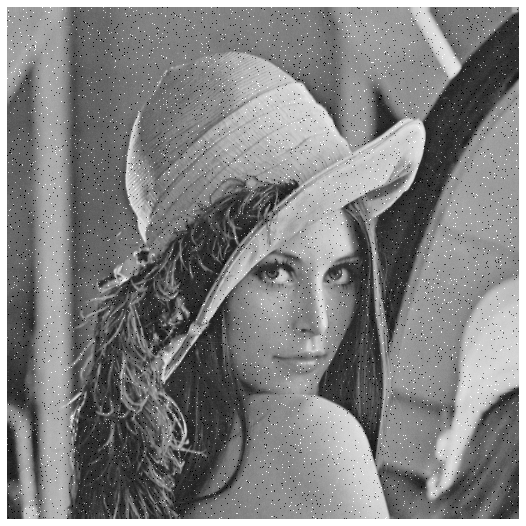

In [19]:
img1 = cv2.imread('images/lena-noise-1.png', 0)
plot_img_orig(img1)

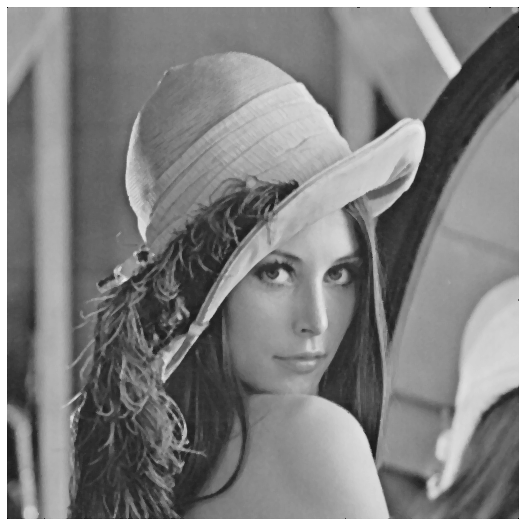

In [20]:
median_img = median_filter(img1, 3)
plot_img_orig(median_img)

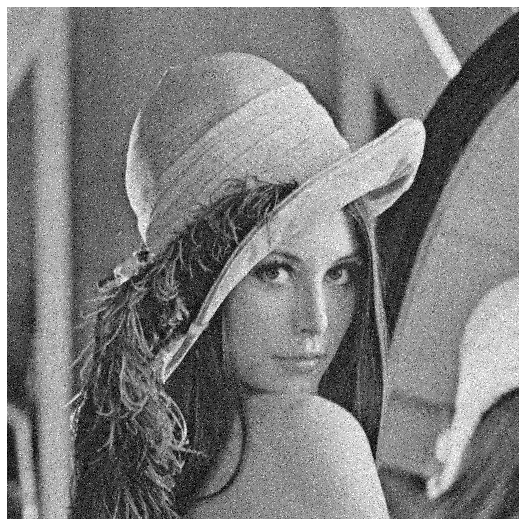

In [21]:
img2 = cv2.imread('images/lena-noise-2.png', 0)
plot_img_orig(img2)

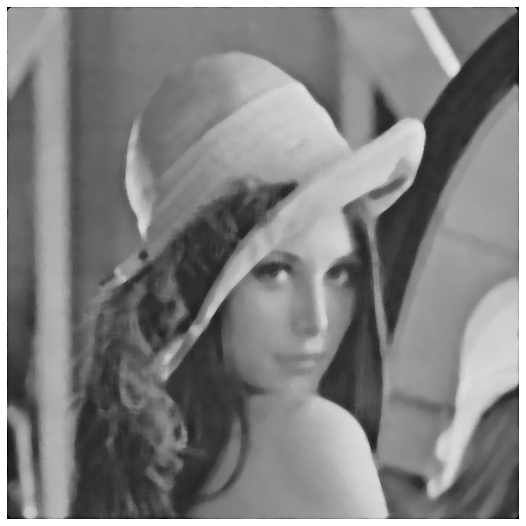

In [22]:
median_img2 = median_filter(img2, 9)
plot_img_orig(median_img2)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 7.4</span> Differentiation of Images

Since averaging is analogous to integration, it is logical to conclude that sharpening can be accomplished by spatial differentiation. In general, the strength of the response of a derivative operator is proportional to the degree of discontinuity of the point at which the operator is applied. As a result, edges and other discontinuties (also noise) are emphasized, while constant or slowly varying gray-level values are deemphasized. The first and second order derivatives of a one-dimensional function $f(x)$ are often defined as follows:

$$
\dfrac{\partial f}{\partial x} = f(x+1) - f(x)
\hspace{1cm}\mathrm{and}\hspace{1cm}
\dfrac{\partial^2 f}{\partial x^2} = f(x+1) + f(x-1) - 2f(x)
$$

Implement / solve the following tasks:
1. Write a function to compute the first and second order derivatives of a given image in the horizontal direction (along the columns). The border can just be left out.
2. Use this function to compute the derivatives for the four test images from the overview.
3. Plot and analyze the result images. It might be necessary to normalize the resulting images (you can use the OpenCV function <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga87eef7ee3970f86906d69a92cbf064bd">`normalize` ↗</a> for this).
4. Plot and analyze the intensity profiles along the middle row for the unnormalized and normalized images.

In [31]:
# write your code here

# compute 1st and 2nd derivatives in horizontal direction (along the cols)
def compute_derivatives(img):
    rows, cols = img.shape # image size
    
    img = img.astype(np.float64) # returns copy of the array, cast to the specified type

    # empty images for the results
    img_d1 = np.zeros(shape=[rows, cols], dtype=np.float64)
    img_d2 = np.zeros(shape=[rows, cols], dtype=np.float64)

    for row in range(rows):
        for col in range(2, cols-2):
            img_d1[row, col] = img[row, col+1] - img[row, col]
            img_d2[row, col] = img[row, col+1] + img[row, col-1] - 2*img[row, col]

    return img_d1, img_d2
    # ...

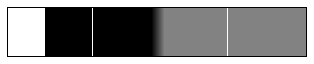

In [35]:
img1 = cv2.imread('images/h-pattern.png', 0)
plot_img_orig(img1)

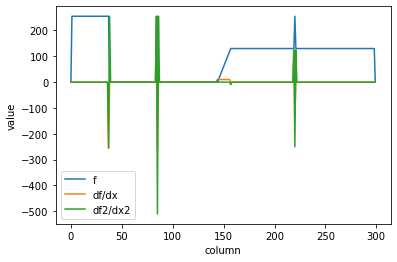

In [40]:
img1_d1, img1_d2 = compute_derivatives(img1)

plt.plot(img1[10,:], label='f')
plt.plot(img1_d1[10,:], label='df/dx')
plt.plot(img1_d2[10,:], label='df2/dx2')

plt.xlabel("column")
plt.ylabel("value")
plt.legend()
plt.show()